# project practice

## case1: Real Estate Market Insights and Valuation
房地产市场洞察与价值评估

### 1. 导入库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.rcParams['font.sans-serif'] = ['SimHei']

### 2. 导入数据

In [2]:
df = pd.read_csv('../data/house_sales.csv')

### 3. 数据概览

In [3]:
print('总记录数：', len(df))
print('字段数量：', len(df.columns))
display(df.head())
df.info()

总记录数： 106118
字段数量： 12


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   city        106118 non-null  object
 1   address     104452 non-null  object
 2   area        105324 non-null  object
 3   floor       104024 non-null  object
 4   name        105564 non-null  object
 5   price       105564 non-null  object
 6   province    106118 non-null  object
 7   rooms       104036 non-null  object
 8   toward      105240 non-null  object
 9   unit        105564 non-null  object
 10  year        57736 non-null   object
 11  origin_url  105564 non-null  object
dtypes: object(12)
memory usage: 9.7+ MB


### 4. 数据清洗

#### 4.1 缺失值处理

In [4]:
# 删除无用的列
df.drop(columns=['origin_url'], inplace=True)
display(df.head())

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建


In [5]:
# 检查是否有缺失值
display(df.isna().sum())

# 删除缺失值
df.dropna(inplace=True)

city            0
address      1666
area          794
floor        2094
name          554
price         554
province        0
rooms        2082
toward        878
unit          554
year        48382
dtype: int64

In [6]:
print('去除空值后的记录数：', len(df))

去除空值后的记录数： 57520


#### 4.2 重复值处理

In [7]:
# 检查是否有重复值
display(df.duplicated().sum())

# 删除重复数据
df.drop_duplicates(inplace=True)

np.int64(29416)

In [8]:
print('数据清洗后的数据记录数：', len(df))

数据清洗后的数据记录数： 28104


In [9]:
display(df.head())

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建
6,合肥,龙岗-长江东路与和县里交口,50㎡,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120㎡,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建


#### 4.3 数据类型转换

In [10]:
# area 的数据类型转换
df['area'] = df['area'].str.replace('㎡', '').astype(float)

In [11]:
# price 的数据类型转换
df['price'] = df['price'].str.replace('万', '').astype(float)

In [12]:
# toward 的数据类型转换
display(df['toward'].value_counts())
df['toward'] = df['toward'].astype('category')

toward
南北向    15946
南向      9405
东南向     1114
东向       448
西南向      308
北向       276
西向       182
东西向      162
西北向      138
东北向      125
Name: count, dtype: int64

In [13]:
# unit 的数据类型转换
df['unit'] = df['unit'].str.replace('元/㎡', '').astype('float')

In [14]:
# year 的数据类型转换
df['year'] = df['year'].str.replace('年建', '').astype(int)

In [15]:
display(df.head())
df.info()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


<class 'pandas.core.frame.DataFrame'>
Index: 28104 entries, 0 to 106088
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   city      28104 non-null  object  
 1   address   28104 non-null  object  
 2   area      28104 non-null  float64 
 3   floor     28104 non-null  object  
 4   name      28104 non-null  object  
 5   price     28104 non-null  float64 
 6   province  28104 non-null  object  
 7   rooms     28104 non-null  object  
 8   toward    28104 non-null  category
 9   unit      28104 non-null  float64 
 10  year      28104 non-null  int64   
dtypes: category(1), float64(3), int64(1), object(6)
memory usage: 2.4+ MB


#### 4.4 异常值处理

In [16]:
# 房屋面积 area 异常值处理
# display(df[df['area'] < 20])
# display(df[df['area'] > 600])

display(len(df[(df['area'] > 20) & (df['area'] < 600)]))

df = df[(df['area'] > 20) & (df['area'] < 600)]

28079

In [17]:
# 房屋售价 price 的异常值处理 IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
high_price = Q3 + 1.5 * IQR
low_price = Q1 - 1.5 * IQR
# display(df[df['price'] < low_price])
# display(df[df['price'] > high_price])
display(len(df[(df['price'] < high_price) & (df['price'] > low_price)]))
df = df[(df['price'] < high_price) & (df['price'] > low_price)]

26135

### 5. 新数据特征构造

In [18]:
display(df.head())

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


In [19]:
# 地区 district
display(df['address'].str.split('-').str[0])
df['district'] = df['address'].str.split('-').str[0]

0            龙岗
2          生态公园
4            撮镇
6            龙岗
8         新亚汽车站
          ...  
106080     万达广场
106082     万达广场
106084     万达广场
106086     利州广场
106088     永隆百货
Name: address, Length: 26135, dtype: object

In [20]:
# 楼层类型 floor_type
# display(df['floor'].str.split('（').str[0])
# df['floor_type'] = df['floor'].str.split('（').str[0].astype('category')

def func1(s):
    if pd.isna(s):
        return '未知'
    elif '低' in s:
        return '低楼层'
    elif '中' in s:
        return '中楼层'
    elif '高' in s:
        return '高楼层'
    else:
        return '未知'

display(df['floor'].apply(func=func1))
df['floor_type'] = df['floor'].apply(func=func1).astype('category')

0         中楼层
2         中楼层
4         中楼层
6         高楼层
8         中楼层
         ... 
106080    中楼层
106082    中楼层
106084    高楼层
106086    低楼层
106088    低楼层
Name: floor, Length: 26135, dtype: object

In [21]:
# 是否是直辖市 is_municipality
# def func2(s):
#     if s in ['北京', '上海', '重庆', '天津']:
#         return 1
#     else:
#         return 0
# display(df['city'].apply(func=func2))
# df['is_municipality'] = df['city'].apply(func=func2)

# display(df['city'].apply(lambda x: 1 if x in ['北京', '上海', '重庆', '天津'] else 0))
# df['is_municipality'] = df['city'].apply(lambda x: 1 if x in ['北京', '上海', '重庆', '天津'] else 0)

display(df['city'].isin(['北京', '上海', '重庆', '天津']).astype(int))
df['is_municipality'] = df['city'].isin(['北京', '上海', '重庆', '天津']).astype(int)

# display(df['province'].isin(['直辖市']).astype(int))
# df['is_municipality'] = df['province'].isin(['直辖市']).astype(int)

# display((df['province'] == '直辖市').astype(int))
# df['is_municipality'] = (df['province'] == '直辖市').astype(int)

0         0
2         0
4         0
6         0
8         0
         ..
106080    0
106082    0
106084    0
106086    0
106088    0
Name: city, Length: 26135, dtype: int64

In [22]:
# 卧室数量 bedroom_count
# display(df['rooms'].str.split('室').str[0].astype(int))
# df['bedroom_count'] = df['rooms'].str.split('室').str[0].astype(int)

display(df['rooms'].str.extract(r'(\d+)室').astype(int))
df['bedroom_count'] = df['rooms'].str.extract(r'(\d+)室').astype(int)

,0
0,3
2,3
4,2
6,2
8,4
...,...
106080,2
106082,2
106084,2
106086,2


In [23]:
# 客厅数量 living_room_count
# display(df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int))
# df['living_room_count'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int)

display(df['rooms'].str.extract(r'(\d+)厅').astype(int))
df['living_room_count'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)

,0
0,2
2,2
4,1
6,1
8,2
...,...
106080,2
106082,2
106084,1
106086,2


In [24]:
# 楼龄 building_age
df['building_age'] = 2026 - df['year']

In [25]:
# 价格分段 price_segment
display(pd.cut(df['price'], bins=4, labels=['低价', '中价', '高价', '豪华']))
df['price_segment'] = pd.cut(df['price'], bins=4, labels=['低价', '中价', '高价', '豪华'])

0         中价
2         中价
4         低价
6         低价
8         高价
          ..
106080    低价
106082    低价
106084    低价
106086    中价
106088    低价
Name: price, Length: 26135, dtype: category
Categories (4, object): ['低价' < '中价' < '高价' < '豪华']

In [26]:
# 检查数据
display(df.sample(5))
display(df.info())
df['is_municipality'].value_counts()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_municipality,bedroom_count,living_room_count,building_age,price_segment
55858,威海,世昌大道-环山路陶家夼隧道西500米红绿灯路南,93.0,低层（共10层）,盛泰·都市枫景,106.4,山东,3室2厅,南北向,11441.0,2019,世昌大道,低楼层,0,3,2,7,中价
22056,榆树,世纪大街-东南湖大路世纪大街交会,75.2,高层（共32层）,像素公园,75.0,吉林,2室2厅,南北向,9973.0,2015,世纪大街,高楼层,0,2,2,11,低价
35506,辛集,天山海世界-珠峰大街218号(珠峰大街与珠江大道交口西北,85.0,高层（共18层）,水榭花都,136.0,河北,2室2厅,南向,16000.0,2010,天山海世界,高楼层,0,2,2,16,中价
12980,徐州,"泰隆商业街-南临徐海路,西接一号路",113.0,中层（共18层）,城置国际花园城,146.0,江苏,3室2厅,南北向,12920.0,2016,泰隆商业街,中楼层,0,3,2,10,中价
80726,湘西,吉首-吉首,125.0,中层（共33层）,吉盟天下世纪山水 华商国际 名门江山 御景园,55.0,湖南,3室2厅,南北向,4400.0,2017,吉首,中楼层,0,3,2,9,低价


<class 'pandas.core.frame.DataFrame'>
Index: 26135 entries, 0 to 106088
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   city               26135 non-null  object  
 1   address            26135 non-null  object  
 2   area               26135 non-null  float64 
 3   floor              26135 non-null  object  
 4   name               26135 non-null  object  
 5   price              26135 non-null  float64 
 6   province           26135 non-null  object  
 7   rooms              26135 non-null  object  
 8   toward             26135 non-null  category
 9   unit               26135 non-null  float64 
 10  year               26135 non-null  int64   
 11  district           26135 non-null  object  
 12  floor_type         26135 non-null  category
 13  is_municipality    26135 non-null  int64   
 14  bedroom_count      26135 non-null  int64   
 15  living_room_count  26135 non-null  int64   
 16  building

None

is_municipality
0    25905
1      230
Name: count, dtype: int64

### 6. 问题分析及可视化

1. 问题1：哪些变量最影响房价？面积、楼层、房间数哪个影响最大？

    分析主题：特征相关性

    分析目标：了解房屋各特征对房屋价格的线性影响

    分组字段：无

    指标/方法：皮尔逊相关系数

,price,area,unit,building_age
price,1.000000,0.452523,0.742731,0.091520
area,0.452523,1.000000,-0.164320,-0.083923
unit,0.742731,-0.164320,1.000000,0.199128
building_age,0.091520,-0.083923,0.199128,1.000000


unit            0.742731
area            0.452523
building_age    0.091520
Name: price, dtype: float64

Text(0.5, 1.0, '房屋特征相关性热力图')

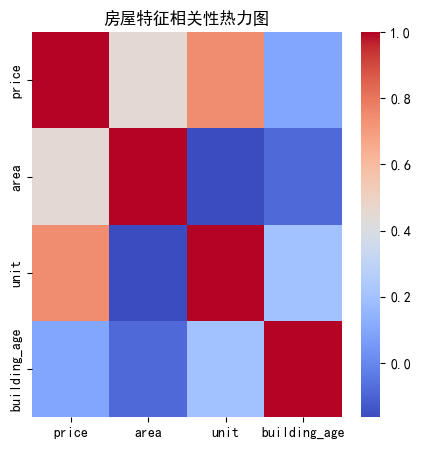

In [27]:
# 选择数值型特征
display(df[['price', 'area', 'unit', 'building_age']].corr())

# 影响房价的几个因素
display(df[['price', 'area', 'unit', 'building_age']].corr()['price'].sort_values(ascending=False)[1:])

# 相关性的热力图
plt.figure(figsize=(5, 5))
sns.heatmap(df[['price', 'area', 'unit', 'building_age']].corr(), cmap='coolwarm')
plt.title('房屋特征相关性热力图')

2. 问题 2 ：全国房价的总体分布是怎么样的？是否存在极端值？

    分析主题：描述性统计

    分析目标：概览数值型字段的分布特征

    分组字段：无

    指标/方法：平均值/中位数/四分位数/方差

In [28]:
display(df.describe())

,area,price,unit,year,is_municipality,bedroom_count,living_room_count,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,0.008800,2.714444,1.848556,12.927760
std,33.995994,60.967675,5824.245273,6.019342,0.093399,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,0.000000,3.000000
25%,85.005000,72.000000,7587.000000,2011.000000,0.000000,2.000000,2.000000,9.000000
50%,100.000000,103.000000,10312.000000,2015.000000,0.000000,3.000000,2.000000,11.000000
75%,123.000000,150.000000,14184.000000,2017.000000,0.000000,3.000000,2.000000,15.000000
max,470.000000,306.000000,85288.000000,2023.000000,1.000000,9.000000,12.000000,50.000000


(array([ 991., 4810., 6499., 4613., 3362., 2226., 1333., 1055.,  691.,
         555.]),
 array([  9. ,  38.7,  68.4,  98.1, 127.8, 157.5, 187.2, 216.9, 246.6,
        276.3, 306. ]),
 <BarContainer object of 10 artists>)

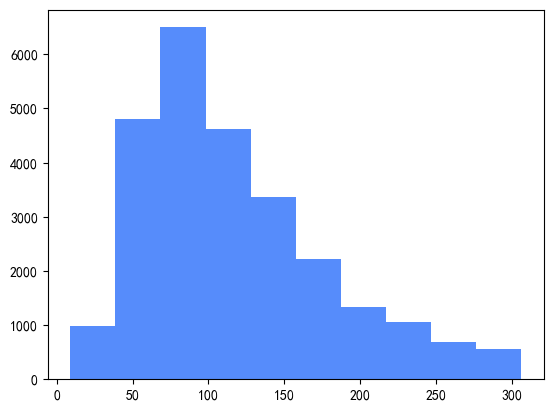

In [29]:
# 房价分布直方图
plt.subplot(1, 1, 1)
plt.hist(df['price'], bins=10)

<Axes: xlabel='price', ylabel='Count'>

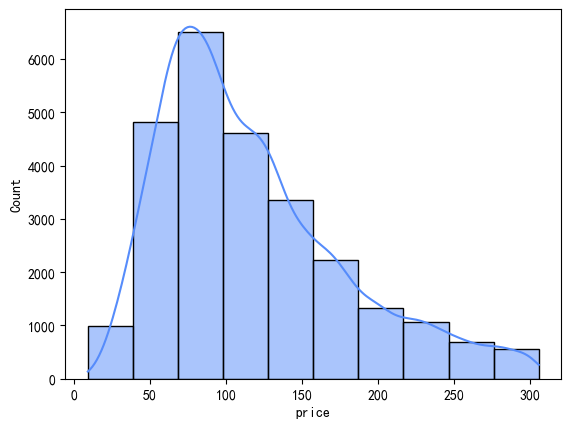

In [30]:
sns.histplot(data=df, x='price', bins=10, kde=True)

3. 问题 3 : 南北向是否比单一朝向贵？贵多少

    分析主题：朝向溢价

    分析目标：评估不同朝向的价格差异

    分组字段：toward

    指标/方法：方差分析/多重比较


In [31]:
df['toward'].value_counts()

toward
南北向    14884
南向      8796
东南向      974
东向       419
北向       258
西南向      254
西向       161
东西向      151
西北向      133
东北向      105
Name: count, dtype: int64

In [34]:
df.groupby('toward', observed=False).agg({
    'price': ['mean', 'median'],
    'unit': 'median',
    'building_age': 'mean'
})

price            unit building_age
              mean median   median         mean
toward                                         
东北向     114.555333  100.0  12198.0    13.609524
东南向     115.542608  105.0  10864.0    11.951745
东向      110.158568   95.0  11421.0    13.761337
东西向      98.935099   82.0   9000.0    16.490066
北向       92.527907   75.5  11698.0    14.108527
南北向     119.472147  104.5  10000.0    13.073703
南向      114.555016  103.0  10759.0    12.551160
西北向     119.107594  105.0  12290.0    14.473684
西南向     139.711811  138.4  13333.0    14.452756
西向      102.662298   86.0  12528.0    14.385093

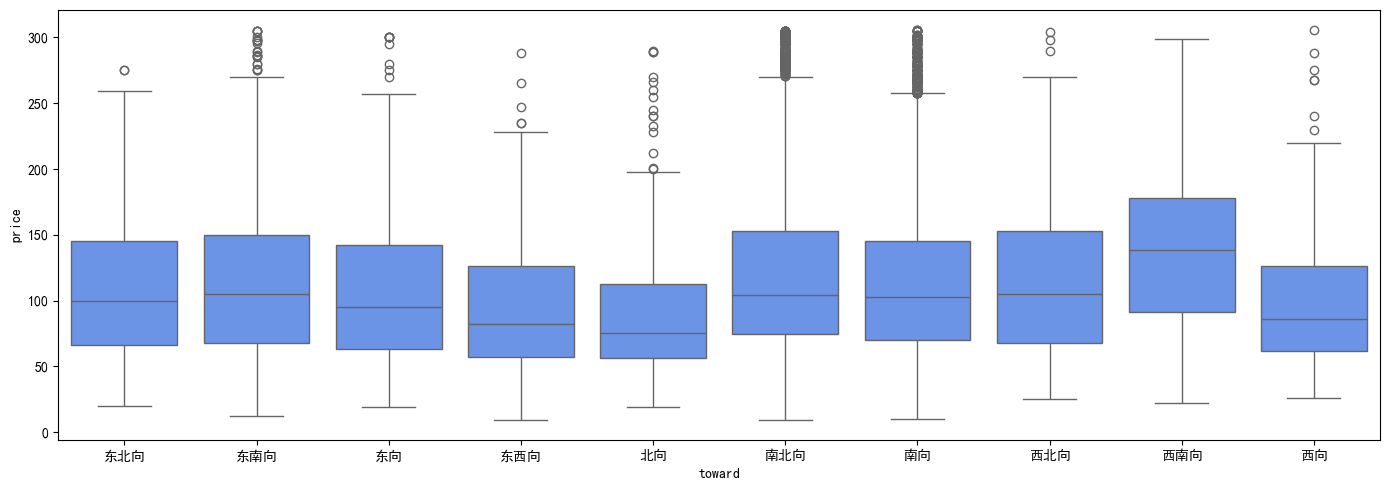

In [36]:
# 数据可视化
plt.figure(figsize=(14, 5))
sns.boxplot(x='toward', y='price', data=df)
plt.tight_layout()